# LSM Benchmarking with TCSPC

## Goal


## Approach & Measurement Setup




### .PTU Decoding

Function routines for decoding PicoQuant .ptu files.

In [52]:
%reset -f

# Importing modules
import sys, struct, io, os
import math
import numpy as np
from numba import jit
import scipy.signal as signal
import matplotlib.pyplot as plt
%matplotlib inline

# Setting up matplotlib for larger plots and retina resolution
from matplotlib import rcParams
%config InlineBackend.figure_format='retina'
rcParams['figure.figsize'] = (10, 8)
rcParams['legend.fontsize']  = 16
rcParams['axes.labelsize'] = 16


# File path to .ptu file to be analysed
#ptupath = '../notebooks/data/HyD_LongTime_Test_12.ptu'
#ptupath = '../app/testData/Convalaria_for_CC_6_1.ptu'
#ptupath = '../app/testData/Coumarin6_18_1.ptu'
#ptupath = '../notebooks/data/191126_DNA_FRETStandard_Lo_2_1.ptu'
#ptupath = '../notebooks/data/20191126_DNA-FRFET-Probe-high_stock_1_1.ptu'
ptupath = '../notebooks/data/TK-E-R51_CMV-mCh-R54_120minNCS_7_1.ptu'

In [53]:
# Functions for ptu record decoding
@jit(nopython=True, cache=True)
def treatOverflows(recordarray, macrotimefactor):
    '''
    Function treatOverflows(
    recordarray: 4 x numRec NumPy array holding raw 32 bit photon records in ['record']
    macrotimefactor: multiplication factor for mactotime clock to recover real experiment macrotime
    )
    Output is recordarray, but with populated ['macrotime'] row
    
    Takes whole record array and recovers real macrotime from raw photon TTTR data by adding
    number of macrotime clock overflows. See PicoQuant PTU documentary for further details and explanation.
    '''
    
    overflow_period = 1024
    overflow_cor = 0

    for record in recordarray:
        if(record['marker'] == 127):
            overflow_cor += overflow_period * \
                (record['record'] & (2**10 - 1))

        record['macrotime'] = (overflow_cor + np.bitwise_and(record['record'], 2**10-1)) * macrotimefactor
            
    return(recordarray)


In [54]:
# Record and header type definitions
tyEmpty8      = struct.unpack(">i", bytes.fromhex("FFFF0008"))[0]
tyBool8       = struct.unpack(">i", bytes.fromhex("00000008"))[0]
tyInt8        = struct.unpack(">i", bytes.fromhex("10000008"))[0]
tyBitSet64    = struct.unpack(">i", bytes.fromhex("11000008"))[0]
tyColor8      = struct.unpack(">i", bytes.fromhex("12000008"))[0]
tyFloat8      = struct.unpack(">i", bytes.fromhex("20000008"))[0]
tyTDateTime   = struct.unpack(">i", bytes.fromhex("21000008"))[0]
tyFloat8Array = struct.unpack(">i", bytes.fromhex("2001FFFF"))[0]
tyAnsiString  = struct.unpack(">i", bytes.fromhex("4001FFFF"))[0]
tyWideString  = struct.unpack(">i", bytes.fromhex("4002FFFF"))[0]
tyBinaryBlob  = struct.unpack(">i", bytes.fromhex("FFFFFFFF"))[0]

rtHydraHarp2T3 = struct.unpack(">i", bytes.fromhex('01010304'))[0]



def readPTUData(path):

    # Open file defined in ptupath
    ptureadstream = open(path, 'rb')

    # Checking file magic and version
    filemagic = ptureadstream.read(8).decode('utf8').strip('\0')

    if(filemagic != 'PQTTTR'):
        print('%s is not a .ptu file!' % ptupath)
        ptureadstream.close()
    #else:
        #print('%s is a valid .ptu file... Commencing.' % ptupath)

    fileversion = ptureadstream.read(8).decode('utf8').strip('\0')
    #print('File Version: %s' % fileversion)


    ## Decoding Header
    ## setting up header end string to terminate header decoding in while loop 
    headerend_tag = 'Header_End'
    reached_headerend = False


    # tuple that stores decoded information from header section
    header_contents = {}

    # decoding header
    while(reached_headerend == False):
        headerpiece = ptureadstream.read(48)
        tagId = headerpiece[0:32].decode('latin1').strip('\0') # Necessary for non-US computer systems (If I remember correcly..., otherwise utf-8 encoding)
        tagIdx = struct.unpack('<i', headerpiece[32:36])[0]
        tagType = struct.unpack('<i', headerpiece[36:40])[0]
        tagVal = headerpiece[40:48]

        if(tagId == headerend_tag):
            reached_headerend = True
            ptureadstream.read(4) # Offset required so that photon records (see second part) are 'in frame'!
            #print('Found Header_End.')
            break

        if(tagType == tyEmpty8):
            header_contents['Empty'] =  'Empty'

        elif(tagType == tyBool8):
            value = struct.unpack('<q', tagVal)[0]
            header_contents[tagId] =  value

        elif(tagType == tyInt8):
            value = struct.unpack('<q', tagVal)[0]
            header_contents[tagId] =  value

        elif(tagType == tyFloat8):
            value = struct.unpack('<d', tagVal)[0]
            header_contents[tagId] =  value

        elif(tagType == tyFloat8Array):
            value = struct.unpack("<q", tagVal)[0]
            print('Float array with %d entries' % value / 8)

        elif(tagType == tyAnsiString):
            value = struct.unpack('<q', tagVal)[0]
            string = ptureadstream.read(value).decode('latin1').strip('\0')
            header_contents[tagId] =  string

        elif(tagType == tyWideString):
            value = struct.unpack('<q', tagVal)[0]
            string = ptureadstream.read(value).decode('utf-16-le').strip('\0')
            header_contents[tagId] =  string

        elif(tagType == tyBinaryBlob):
            value = struct.unpack("<q", tagVal)[0]
            header_contents[tagId] =  value

        elif(tagType == tyBitSet64):
            value = struct.unpack('<q', tagVal)[0]
            header_contents[tagId] =  value

        elif(tagType == tyColor8):
            value = struct.unpack('<q', tagVal)[0]
            header_contents[tagId] =  "{0:#0{1}x}".format(value,18)

        elif(tagType == tyBinaryBlob):
            value = struct.unpack('<q', tagVal)[0]
            header_contents[tagId] =  value

        elif(tagType == tyTDateTime):
            print(' ')

        else:
            continue
            #print('Unknown header tag type. Ignored.')


    headerend_bitoffset = ptureadstream.tell() # Needed to quickly jump to photon records instead of header

    #print('Finished decoding header.')

    # Copying header info into FLIMInfo dict
    FLIMInfo = {
        #'Filename' : header_contents['$Filename'],
        #'Comment': header_contents['$Comment'],
        'RecordType' : header_contents['TTResultFormat_TTTRRecType'],
        'BitsPerRecord' : header_contents['TTResultFormat_BitsPerRecord'],
        #'PixelResolution' : header_contents['$ReqHdr_SpatialResolution'],
        'PixelsX' : header_contents['ImgHdr_PixX'],
        'PixelsY' : header_contents['ImgHdr_PixY'],
        'GlobalResolution' : header_contents['MeasDesc_GlobalResolution'],
        'BaseResolution' : header_contents['HW_BaseResolution'],
        'Resolution' : header_contents['MeasDesc_Resolution'],
        'BinningFactor' : header_contents['MeasDesc_BinningFactor'],
        'SyncRate' : header_contents['TTResult_SyncRate'],
        'NumberOfRecords' : header_contents['TTResult_NumberOfRecords']
    }

    # Closing read stream
    ptureadstream.close()


    # Reading photon records from ptu file, reopening read stream at headerend_bitoffset
    ## Initializing record array with pre-defined data types and length (read from header -> NumberOfRecords)
    recordBitType = np.dtype([('record', np.uint32), ('marker', np.uint8),
                                  ('nanotime', np.float64), ('macrotime', np.float64)])
    recordarray = np.zeros(
            shape=FLIMInfo['NumberOfRecords'] - 1, dtype=recordBitType)

    ## Getting macro and nano time conversion factors from FLIMInfo
    macroMultFactor = FLIMInfo['GlobalResolution']
    nanoMultFactor = FLIMInfo['Resolution'] * 1e9

    ## Dumping records into recordarray
    with open(path, 'rb') as file:
        file.seek(headerend_bitoffset)
        recordarray[:]['record'] = np.fromfile(file, dtype=np.uint32)
        file.close()

    ## Recover marker signals and nano times by bitwise operations on recordarray['record']
    recordarray[:]['marker'] = (np.right_shift(recordarray[:]['record'], 25) & 127)
    recordarray[:]['nanotime'] = (np.right_shift(recordarray[:]['record'], 10) & 32767) * nanoMultFactor

    # Recover macro times using treatOverflows()
    recordarray = treatOverflows(recordarray, macroMultFactor)

    # Delete raw bit records from recordarray (['record'])
    macrotimes = np.array(recordarray['macrotime'], dtype = np.float64)
    nanotimes = np.array(recordarray['nanotime'], dtype = np.float64)
    markers = np.array(recordarray['marker'], dtype = np.uint8)
    del recordarray

    #print('\n*********\nFinished decoding .ptu file. recordarray can now be used.')
    
    return(macrotimes, nanotimes, markers, header_contents)

In [55]:
#for k in header_contents:
#    print(k, "...\t", header_contents[k])

## Data Analysis

In [56]:
# Reading test data
macrotimes, nanotimes, markers, header_contents = readPTUData('../notebooks/data/Fluoresceine Time Series/191214_Long_test_fluoresceine1.ptu')

In [57]:
# Checking the markers axis for all events
## 0 to 3 encode photon events, 65 and higher encode microscope (line, frame, ...) events, 127 is a macro time clock overflow
for i in range(0, 128):
    num = np.sum(markers == i)
    if(num != 0):
        print(num, "events for marker code ", i, ".")

7359738 events for marker code  0 .
128 events for marker code  65 .
127 events for marker code  66 .
1 events for marker code  70 .
4568654 events for marker code  127 .


In [58]:
# Calculatung length of macro time axis, Microscope was setup to scan one frame every five minutes and repeat that 30 times: 5 min * 30 = 2.5 h
## macrotime is in s! (CAVE: I converted the macrotimes array to s; in header it is in ms [see PQ PTU documentary!])´
timediff = (macrotimes[-1] - macrotimes[0])/(60**2)
print("Time difference between first and last macro time clock entry is ", round(timediff, 3), " hours (", len(macrotimes), "macrotime entries).")

Time difference between first and last macro time clock entry is  7.159  hours ( 11928648 macrotime entries).


In [59]:
# Calculating reasonable number of bins for macrotimes histogram -> 10 ms / bin
bins = int(macrotimes[-1]/1) # max macro time in s / 10 ms
print(bins)

### Marker event used for further analysis
selected_marker = 0

25772


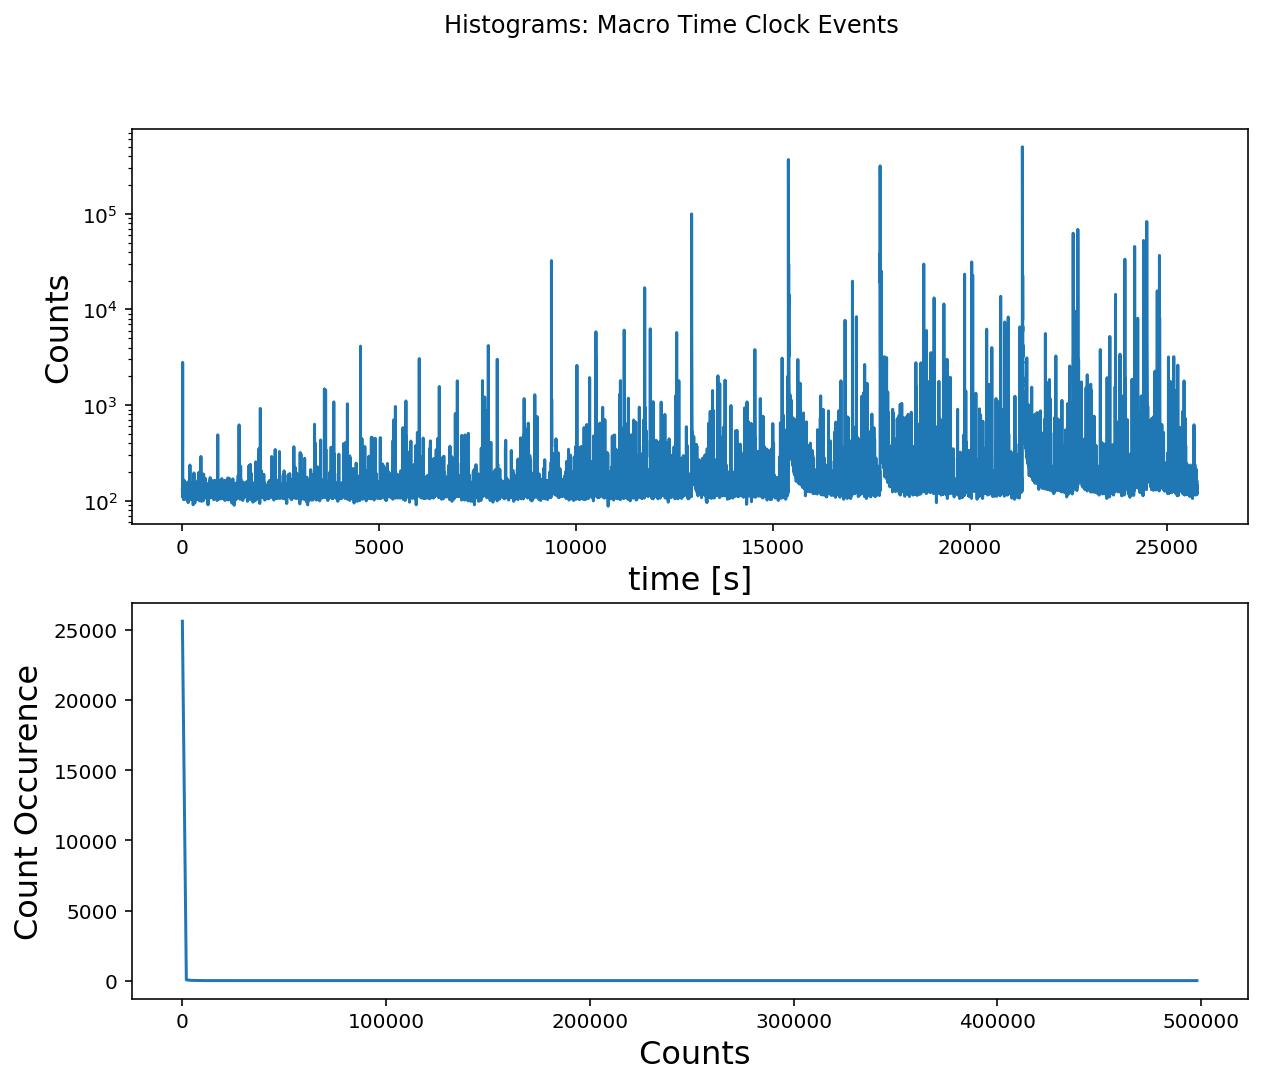

In [60]:
# Calculate macrotimes histogram
macrotimes_hist_c1 = np.histogram(macrotimes[np.where(markers == selected_marker)], bins = bins)
macrotimes_eventfreq = np.histogram(macrotimes_hist_c1[0], bins = int(bins*0.01))

fig, axs = plt.subplots(2)
fig.suptitle('Histograms: Macro Time Clock Events')
axs[0].plot(macrotimes_hist_c1[1][:-1], macrotimes_hist_c1[0], '-')
axs[0].set(ylabel = 'Counts', xlabel = 'time [s]', yscale = 'log')#, xlim = (21000, 21800))
axs[1].plot(macrotimes_eventfreq[1][:-1], macrotimes_eventfreq[0])
axs[1].set(ylabel = 'Count Occurence', xlabel = ' Counts', yscale = 'linear')
plt.show()

In [61]:
c1_selection = nanotimes[0:10000]
#ns_hist_c1 = np.histogram(nanotimes[np.where(markers == 0)], bins = 3214)
ns_hist_c1 = np.histogram(c1_selection, bins = 3214)
ns_hist_c2 = np.histogram(nanotimes[np.where(markers == 1)], bins = 3214)

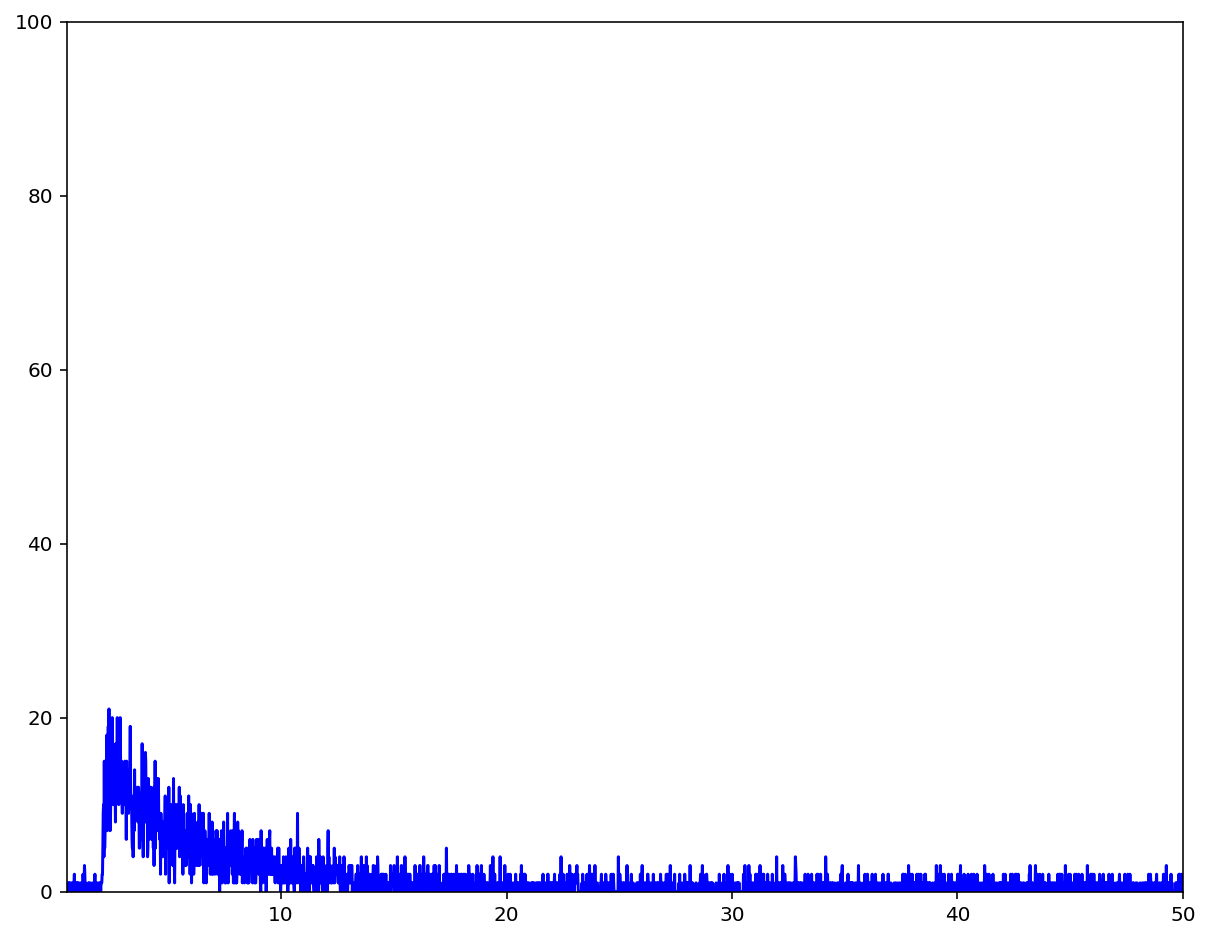

In [62]:
plt.plot(ns_hist_c1[1][:-1], ns_hist_c1[0], 'b-')
plt.xlim(0.5, 50)
plt.ylim(0, 100)
plt.yscale('linear')
plt.show()

## Notch Filter Test
The pulsed white light laser (WLL) of the Leica SP8 system was tested for laser pulse bleed-through using an hybrid detector and the HydraHarp V2 TCSPC system. Laser emission was set to $488 \ nm$ and the detection edge of the hydrid detector was shifted from $500 \ nm$ to $498 \ nm$, $495 \ nm$, $493 \ nm$, $490 \ nm$, $489 \ nm$, $488 \ nm$, and $485 \ nm$ (total detection range of $50 \ nm$). During the first repetition, the notch filter for $488 \ nm$ was used, in the second repetition no notch filter was used.

The readPTUData() function, defined above, returns macro time, nano time, marker, and header arrays. The nano times are put in a histogram and plotted using the matplotlib module. The effect of the notch filter is shown.

In [63]:

# Without Notch Filter
woNF_500 = np.array(readPTUData('../notebooks/data/Notch Filter Test/191214_NFTest_488_woNF_9/191214_NFTest_488_woNF_9_1.ptu'))
woNF_500_hist = np.histogram(woNF_500[1][np.where(woNF_500[2] == 0)], bins = 3214)

woNF_495 = np.array(readPTUData('../notebooks/data/Notch Filter Test/191214_NFTest_488_woNF_11/191214_NFTest_488_woNF_11_1.ptu'))
woNF_495_hist = np.histogram(woNF_495[1][np.where(woNF_495[2] == 0)], bins = 3214)

woNF_493 = np.array(readPTUData('../notebooks/data/Notch Filter Test/191214_NFTest_488_woNF_12/191214_NFTest_488_woNF_12_1.ptu'))
woNF_493_hist = np.histogram(woNF_493[1][np.where(woNF_493[2] == 0)], bins = 3214)

woNF_490 = np.array(readPTUData('../notebooks/data/Notch Filter Test/191214_NFTest_488_woNF_13/191214_NFTest_488_woNF_13_1.ptu'))
woNF_490_hist = np.histogram(woNF_490[1][np.where(woNF_490[2] == 0)], bins = 3214)

woNF_489 = np.array(readPTUData('../notebooks/data/Notch Filter Test/191214_NFTest_488_woNF_14/191214_NFTest_488_woNF_14_1.ptu'))
woNF_489_hist = np.histogram(woNF_489[1][np.where(woNF_489[2] == 0)], bins = 3214)

woNF_488 = np.array(readPTUData('../notebooks/data/Notch Filter Test/191214_NFTest_488_woNF_15/191214_NFTest_488_woNF_15_1.ptu'))
woNF_488_hist = np.histogram(woNF_488[1][np.where(woNF_488[2] == 0)], bins = 3214)

woNF_485 = np.array(readPTUData('../notebooks/data/Notch Filter Test/191214_NFTest_488_woNF_16/191214_NFTest_488_woNF_16_1.ptu'))
woNF_485_hist = np.histogram(woNF_485[1][np.where(woNF_485[2] == 0)], bins = 3214)

In [64]:
for k in woNF_485[3]:
    print(k, woNF_485[3][k])

File_GUID {DD662F0C-9F4E-4A55-85B3-FA300D77D9F7}
$StartedByRemoteInterface -1
Measurement_SubMode 3
File_Comment LAS X 2.0.1.14392
Notch filter test with water sample. HyD1 set to detection range of 485 to 535 nm. WLL set to 70 % global and 5 % local intensity. Without NF.
Pinhole: 58.69 µm
Objective: HC FLUOTAR L 25.0 WATER
Image Format: 128 x 128
Scan Speed: 100 Hz
Zoom: 1.0
Frame Average: 100
Direction: Unidirectional

WLL
 LaserLine 488: 5.0
 Laser Shutter: Open

Laser (WLL, WLL) On 70.0
Laser (Argon, visible) Off 0.0
Laser (IR, MP) On
Laser (IR2, FSOPO) On
MFP Filter: Substrate 
Polarization Filter: Empty
Notch Filter: Empty
X1-Port: Mirror 
Scan Mode: xyz
ZPosition: 0.00 µm
Spectral detection range
SP PMT 1: 485...535nm 

FLIM Detector: Intern
Acquisition Mode: Frame Repetition 100

TTResult_StopReason 1
Empty Empty
CreatorSW_Name SymPhoTime 64
CreatorSW_Version 2.1
CreatorSW_SVNBuild 3813
CreatorSW_Modules 0
$ReqHdr_RecordVersion 16777728
$ReqHdr_MeasurementType 1
$ReqHdr_PixelN

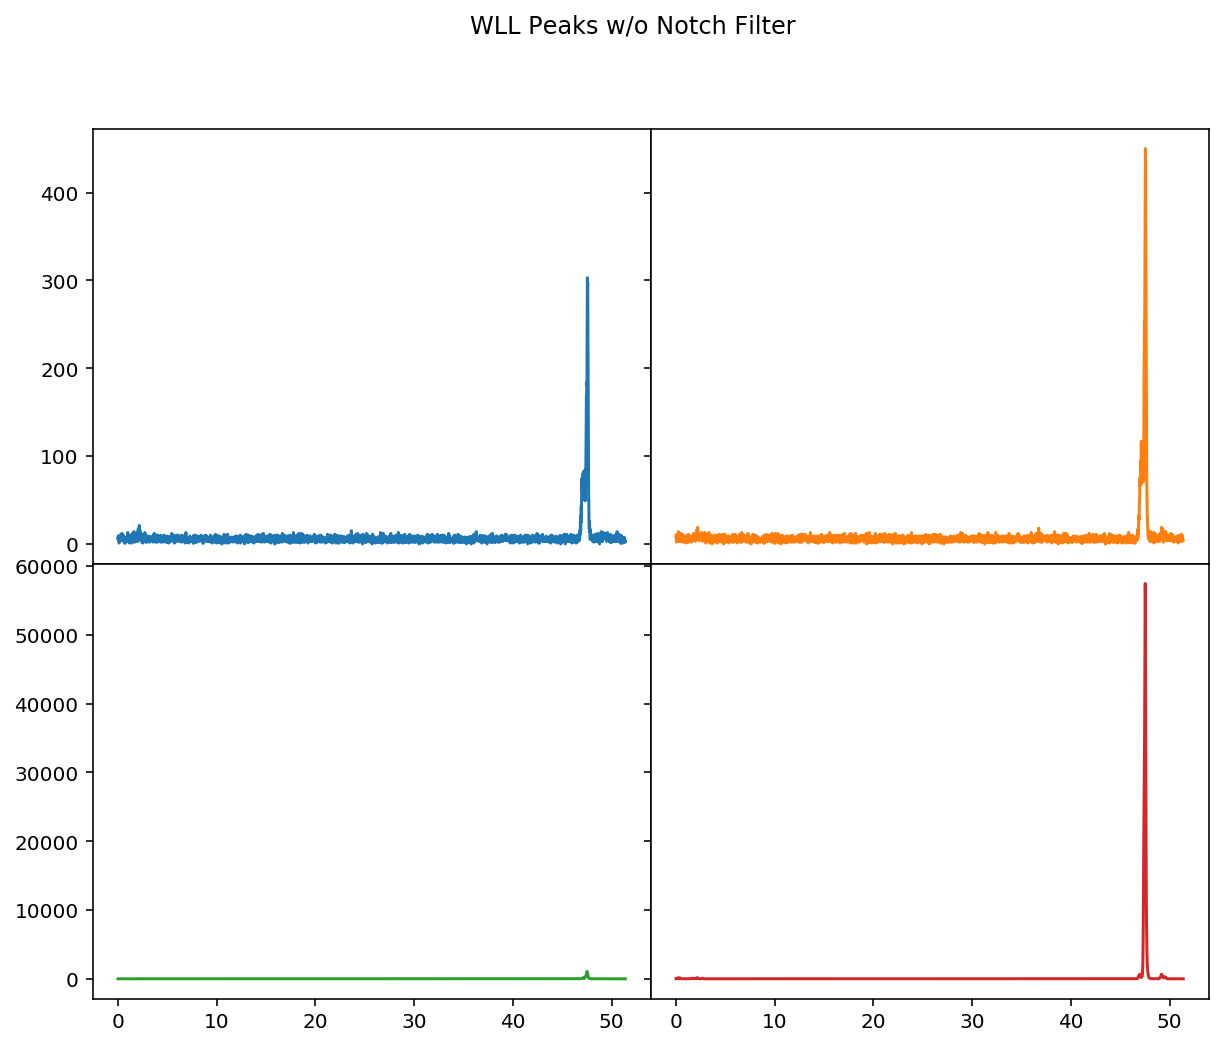

In [66]:
# Making subplots for peak visualization

fig, axs = plt.subplots(2, 2, sharex='col', sharey='row',
                        gridspec_kw={'hspace': 0, 'wspace': 0})
(ax1, ax2), (ax3, ax4) = axs
fig.suptitle('WLL Peaks w/o Notch Filter')
ax1.plot(woNF_500_hist[1][:-1], woNF_500_hist[0])
ax2.plot(woNF_495_hist[1][:-1], woNF_495_hist[0], 'tab:orange')
ax3.plot(woNF_493_hist[1][:-1], woNF_493_hist[0], 'tab:green')
ax4.plot(woNF_490_hist[1][:-1], woNF_490_hist[0], 'tab:red')

for ax in axs.flat:
    ax.label_outer()